In [50]:
import pandas as pd
import numpy as np

In [51]:
df = pd.read_csv('./datasets/diabetes/data_for_lr.csv')
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [52]:
x_total = df['x'].sum()
y_total = df['y'].sum()

x_avg = df['x'].mean()
y_avg = df['y'].mean()

print(f"X sum = {x_total}")
print(f"Y sum = {y_total}")
print(f"X avg = {x_avg}")
print(f"Y avg = {y_avg}")

X sum = 38490.15736917
Y sum = 34907.96855015
X avg = 54.98593909881429
Y avg = 49.9398691704578


In [53]:
# y = mx + c

# m = [n(sum of xy) - (sum of x)(sum of y) ] // n(sum of x sqr) - sqr(sum of x)

# c = (sum of y) - m (sum of x) // n

In [54]:
df['xy'] = df['x'] * df['y']
df.head(5)

,x,y,xy
0,24.0,21.549452,517.186847
1,50.0,47.464463,2373.223152
2,15.0,17.218656,258.279845
3,38.0,36.586398,1390.283125
4,87.0,87.288984,7594.141598


In [55]:
df['x sqr'] = df['x']**2
df.head()

,x,y,xy,x sqr
0,24.0,21.549452,517.186847,576.0
1,50.0,47.464463,2373.223152,2500.0
2,15.0,17.218656,258.279845,225.0
3,38.0,36.586398,1390.283125,1444.0
4,87.0,87.288984,7594.141598,7569.0


In [56]:
n = df.shape[0]
print(f'Number of rows = {n}')

Number of rows = 700


In [57]:
# according to formula of linear regression

# m = [n(sum of xy) - (sum of x)(sum of y) ] // n(sum of x sqr) - sqr(sum of x)

sum_of_xy = df['xy'].sum()
sum_of_x_sqr = df['x sqr'].sum()


m = (n * (sum_of_xy) - (x_total * y_total) ) / ((n*sum_of_x_sqr) - x_total **2)
print(f'value of m = {m}')

value of m = 0.03249510695536494


In [58]:
# c = (sum of y) - m (sum of x) // n

c = (y_total - m*x_total) / n
print(f'value of c = {c}')

value of c = 48.081752528157125


In [59]:
# y_pred = m*x + c

df['y_pred'] = m*df['x'] + c
df.head(5)

,x,y,xy,x sqr,y_pred
0,24.0,21.549452,517.186847,576.0,48.861635
1,50.0,47.464463,2373.223152,2500.0,49.706508
2,15.0,17.218656,258.279845,225.0,48.569179
3,38.0,36.586398,1390.283125,1444.0,49.316567
4,87.0,87.288984,7594.141598,7569.0,50.908827


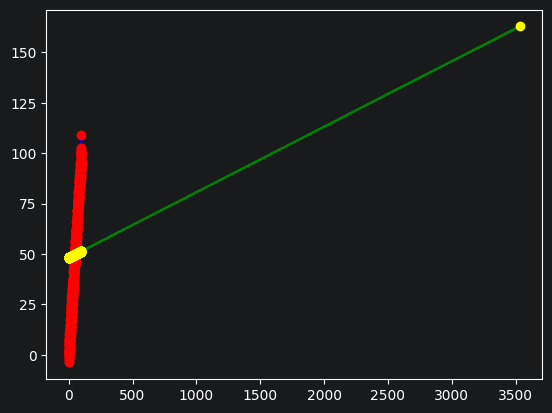

In [60]:
import matplotlib.pyplot as plt

plt.plot(df['x'], df['y'],
         color='blue', marker='o',
         markerfacecolor='red',
         markeredgecolor='red',)

plt.plot(df['x'], df['y_pred'],
         color='green', marker='o',
         markerfacecolor='yellow',
         markeredgecolor='yellow',)

plt.show()

- Checking the values of m and c using library for Linear regression

In [61]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

In [62]:
# Independent variable (X)
X = df[['x']]

# Dependent variable (Y)
y = df['y']

In [63]:
# Train the model
lr_model.fit(X, y)

ValueError: Input y contains NaN.

In [64]:
# y = y.dropna()

In [ ]:
# lr_model.fit(X, y)


# Note: if we remove the nan value only from the y then we will get the following inconsitency and error -

#  Found input variables with inconsistent numbers of samples: [700, 699]

# hence we have to remove the entire row of the data

In [65]:
df = pd.read_csv(
    './datasets/diabetes/data_for_lr.csv', )
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [66]:
x = df[['x']]
y = df['y']

In [67]:
nan_indices = y[y.isna()].index

In [68]:
nan_indices

Index([213], dtype='int64')

In [69]:
df = df.drop(index=nan_indices)

In [ ]:
df.describe()

In [70]:
df['x'].isna().count()

np.int64(699)

In [71]:
df['y'].isna().count()

np.int64(699)

In [72]:
lr_model.fit(x, y)

ValueError: Input y contains NaN.

In [73]:
# Remove rows where target column contains NaN
df = df.dropna(subset=['y'])

# Now create X and y
X = df.drop('y', axis=1)
y = df['y']

In [75]:
print(x.isna().sum())

x    0
dtype: int64


In [76]:
lr_model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [77]:
print(lr_model.coef_)
print(lr_model.intercept_)

[1.00065638]
-0.10726546430097272


In [78]:
print(m)
print(c)

0.03249510695536494
48.081752528157125


In [80]:
df['y_model'] = lr_model.predict(df[['x']])

In [81]:
df.head(5)

,x,y,y_model
0,24.0,21.549452,23.908488
1,50.0,47.464463,49.925554
2,15.0,17.218656,14.902580
3,38.0,36.586398,37.917677
4,87.0,87.288984,86.949840
